# `06-workflow.ipynb`

In [1]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

llm = init_chat_model('gpt-4.1-mini')

## Prompt Chaining

- 매우 잘 정리된 업무 순서가 있을 경우 사용
- 이전 노드에서 처리한 내용을 `state`에 담아 다음 노드로 전송


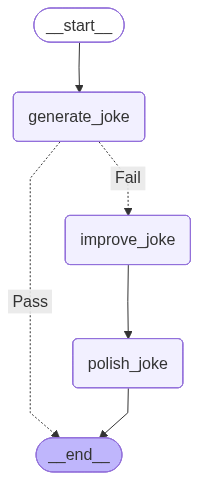

{'topic': '졸림',
 'joke': '“왜 졸릴 때 수업이 더 재미있게 느껴질까?  \n잠이 와서 뇌가 ‘여기서 쉬어도 돼’라고 신호를 보내거든!”'}

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END, MessagesState
# 그림 보는 용
from IPython.display import Image, display

# Graph State
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# Nodes 
def generate_joke(state: State):
    msg = llm.invoke(f'주제 {state['topic']}에 관련된 짧은 농담 생성')
    return {'joke': msg.content}


def improve_joke(state: State):
    msg = llm.invoke(f'말장난을 추가해서 아래 농담을 더 재밌게 만들어보자.\n {state['joke']}')
    return {'improved_joke':msg.content}


def polish_joke(state: State):
    msg = llm.invoke(f'아래 농담을 쩔게 뒤틀어 보자\n {state['improved_joke']}')
    return {'final_joke':msg.content}

# Router
def check_puchline(state: State):
    # ? 나 ! 없으면, improve하고, 있으면 그대로 진행
    if '?' in state['joke'] or '!' in state['joke']:
        return 'Pass'
    else:
        return 'Fail'
    

workflow= StateGraph(State)
workflow.add_node('generate_joke',generate_joke)  # workflow.add_node(generate_joke) 
workflow.add_node('improve_joke',improve_joke)
workflow.add_node('polish_joke',polish_joke)

workflow.add_edge(START, 'generate_joke')
workflow.add_conditional_edges('generate_joke', check_puchline, {'Pass': END,'Fail': 'improve_joke'} )
workflow.add_edge('improve_joke','polish_joke')
workflow.add_edge('polish_joke',END)
                               
graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


graph.invoke({'topic': '졸림'})

## Parallelization (병렬화) (비동기)
- 여러 node(llm)이 동시에 작업을 진행
- 뭐가 먼저 끝날지 알 수 없음
- 하위 task를 동시에 진행시켜서 속도 up
- 같은 task를 여러번 동시에 돌려서 신뢰성 확보 

In [3]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    output: str

# Nodes
def generate_joke(state: State):
    msg = llm.invoke(f'Write a joke about {state['topic']}')
    return {'joke':msg.content}

def generate_story(state: State):
    msg = llm.invoke(f'Write a story about {state['topic']}')
    return {'story':msg.content}

def generate_poem(state: State):
    msg = llm.invoke(f'Write a pem about {state['topic']}')
    return {'poem':msg.content}

def aggregate(state:State):
    output= f""" 농담, 이야기, 시
                Joke : {state['joke']}
                Story: {state['story']}
                Poem:{state['poem']}
            """
    return {'output':output}

workflow= StateGraph(State)
workflow.add_node(generate_joke)  # workflow.add_node(generate_joke) 
workflow.add_node(generate_story)
workflow.add_node(generate_poem)
workflow.add_node(aggregate)

workflow.add_edge(START, 'generate_joke')
workflow.add_edge(START, 'generate_story')
workflow.add_edge(START, 'generate_poem')
workflow.add_edge('generate_joke', 'aggregate')
workflow.add_edge('generate_story', 'aggregate')
workflow.add_edge('generate_poem', 'aggregate')
workflow.add_edge('aggregate',END)
                               
graph = workflow.compile()
graph

graph.invoke({'topic': '배고픔'})

{'topic': '배고픔',
 'joke': '배고픔이 너무 심할 때 친구가 물었어요:  \n"배고파?"  \n내가 대답했죠: "아니, 내 배가 반찬 먹으러 가는 중이야!"',
 'story': '옛날 어느 작은 마을에 ‘수지’라는 소녀가 살고 있었습니다. 수지는 항상 배고픔을 느꼈습니다. 마을에는 먹을 것이 넉넉하지 않았고, 수지의 가족도 겨우 하루하루를 견뎌내고 있었기 때문입니다.\n\n어느 날, 수지는 배고픔을 이기지 못하고 마을 밖 숲으로 나갔습니다. 그녀는 배고픔을 달래기 위해 무엇이든 찾아 먹고 싶었지만, 숲은 무서웠고 아무것도 쉽게 구할 수 없었지요. 그러다 우연히 반짝이는 작은 열매를 발견했습니다. 그것은 마치 보석처럼 빛나고 있었기에 수지는 조심스럽게 그 열매를 따서 한 입 베어 물었습니다.\n\n그 순간, 그녀의 몸에는 따뜻한 힘이 퍼지며 배고픔이 사라지고 상쾌함이 찾아왔습니다. 신기한 열매 덕분에 수지는 힘을 내어 집으로 돌아왔고, 마을 사람들에게 이 열매의 존재를 알렸습니다.\n\n마을 사람들은 함께 숲으로 가서 그 신비한 열매를 찾아냈고, 배고픔에 시달리던 이들은 점차 기운을 회복할 수 있었습니다. 수지는 그때부터 ‘희망의 열매’라 불리는 이 작은 보물 덕분에 배고픔에 맞서 용기와 지혜를 잃지 않게 되었습니다.\n\n배고픔은 단순한 신체적 고통을 넘어서 사람들에게 더 큰 연대와 끈기를 심어주었고, 수지와 마을 사람들은 함께 어려움을 극복하며 더욱 단단한 공동체가 될 수 있었습니다.',
 'poem': '배고픔\n\n속삭이는 배고픔,  \n빈속에 파도처럼 밀려와,  \n가만히 귀 기울이면  \n숨결 사이로 꿈틀거린다.  \n\n차가운 공기마저 스며들고,  \n손끝은 가벼운 떨림을 품어,  \n잊혀진 기억 속 입맛을  \n조용히 불러낸다.  \n\n배고픔은 단순한 신호가 아닌,  \n생명의 노래,  \n우리가 살아있음을 알려주는  \n작은 심장의 울림이다.',
 'output': ' 농담, 이야기, 시\n                Jok

from pydantic import BaseModel, Field 

 - Pydantic 으로 structured output 데이터 형식 클래스로 선언 시  -> Pydantic 모델 인스턴스로 생성됨


In [ ]:
from typing import Literal
from langchain.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

class State(TypedDict):
    input: str
    decision: str
    output: str


# Router에서 사용할 LLM이 쓸 structured output
# {'step': 'poem' | 'story' | 'joke' }
class Route(BaseModel):                      # step 이란 필드는 3개 중 하나지만, 필수(...)고 설명은 ~~ 이다
    step: Literal['poem', 'story', 'joke'] = Field(..., description= 'next step in routing process') 

router_llm = llm.with_structured_output(Route)


# Nodes
# -> state['decision']을 결정하는 Node 

def decision_node(state:State):
    result = router_llm.invoke(
            [
                SystemMessage(content='사용자 요청에 따라 story, joke, poem을 선택'),
                HumanMessage(content=state['input'])
            ]
        )
    
    return {'decision': result.step}  # router_llm.with_structured_output(Route)로 호출하면 반환값이 딕셔너리가 아니라 Pydantic 모델 인스턴스 -> Route(step='poem')

'''
{'step' : 'poem'}
'''


def generate_joke(state: State):
    msg = llm.invoke(
        [
            SystemMessage(content='아주 기발하되 고급스러운 유머를 만들어야 함'),
            HumanMessage(content = state['input'])
            
        ]  
            )
    return {'output':msg.content}

def generate_story(state: State):
    msg = llm.invoke(state['input'])
    return {'output':msg.content}

def generate_poem(state: State):
    msg = llm.invoke(state['input'])
    return {'output':msg.content}


# Router 
def route_decision(state: State):
    return state['decision']

workflow = StateGraph(State)

workflow.add_node(decision_node)
workflow.add_node(generate_joke)
workflow.add_node(generate_poem)
workflow.add_node(generate_story)


workflow.add_edge(START, 'decision_node')
workflow.add_conditional_edges(
    'decision_node',
    route_decision,
    {
        'joke': 'generate_joke',
        'story': 'generate_story',
        'poem': 'generate_poem'
    }
)
workflow.add_edge('generate_joke',END)
workflow.add_edge('generate_story',END)
workflow.add_edge('generate_poem',END)
graph = workflow.compile()

graph.invoke({'input':'나 심심해'})



/Users/kimsiyeon/Desktop/gaida-2/04-langgraph/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Route(step='joke'), input_type=Route])
  return self.__pydantic_serializer__.to_python(


{'input': '나 심심해',
 'decision': 'joke',
 'output': '심심하다면, 이렇게 한 번 웃어볼까요?\n\n“철학자가 커피를 마시면서 한탄했대요.  \n‘내 존재가 증명된다면, 그건 커피 덕분일지도 몰라.  \n왜냐면 나는 생각한다, 고로 나는 마신다.’  \n\n커피 한 잔에 철학까지 녹아드는 고급스러운 여유,  \n이 정도면 심심할 틈도 없겠죠?”  \n\n필요하면 더 기발한 유머도 준비할게요!'}

## Orchestrator - Worker
- 태스크를 서브태스크로 쪼갬
- 해당 서브태스크를 담당하는 워커에게 분배
- 모든 서브태스크들의 output을 최종 결과로 정리

- 오케스트레이션에서 서브 태스크 여러개를 나눠서 (즉 섹션이 여러개가 필요)


In [ ]:
from typing import Annotated, List
from pydantic import BaseModel, Field

# Structured Output 용 Model 생성 (계획 수립)
# Section (name = '~', desciption='' )
class Section(BaseModel):
    name: str = Field(..., description='보고서내 해당 섹션명')
    desciption : str = Field(..., description='해당 섹션에서 다룰 주요 주제 및 개념에 대한 개요')

# Sections(sections =[ [Section(),Section(),Section(),  ] )
class Sections(BaseModel):
    sections: List[Section] = Field(..., description='리포트의 섹션들')

planner_llm = llm.with_structured_output(Sections)

# planner_llm.invoke('LLM 스케일링 법칙에 대한 레포트 작성해줘')



/Users/kimsiyeon/Desktop/gaida-2/04-langgraph/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sections(sections=[Sectio...다시 강조한다.')]), input_type=Sections])
  return self.__pydantic_serializer__.to_python(


Sections(sections=[Section(name='소개', desciption='LLM(대형 언어 모델) 스케일링 법칙의 기본 개념과 중요성을 설명한다. 이러한 법칙이 인공지능 연구와 응용에 미치는 영향에 대해 간략히 소개한다.'), Section(name='스케일링 법칙의 정의', desciption='스케일링 법칙이란 무엇인지 정의하고, 모델 크기, 데이터 양, 계산 자원 등이 성능에 어떻게 영향을 미치는지 설명한다.'), Section(name='주요 연구 결과', desciption='OpenAI, Google 등 주요 기관에서 발표한 스케일링 법칙에 관한 연구 결과를 정리한다. 모델 크기와 성능 간의 관계, 학습 곡선 등을 포함한다.'), Section(name='스케일링 법칙의 적용 사례', desciption='LLM 개발 및 서비스에서 스케일링 법칙이 어떻게 적용되는지 실제 사례를 통해 설명한다. 예를 들어 GPT 시리즈, PaLM 등의 모델을 소개한다.'), Section(name='한계점 및 도전 과제', desciption='스케일링 법칙 적용 시 발생하는 문제점과 한계를 소개하고, 효율적인 모델 학습 및 활용을 위한 도전 과제를 논의한다.'), Section(name='미래 전망', desciption='스케일링 법칙 기반 LLM 연구의 향후 방향과 인공지능 기술 발전에 미칠 영향을 전망한다.'), Section(name='결론', desciption='레포트의 주요 내용을 요약하고, 스케일링 법칙이 인공지능 분야에서 가지는 의미를 다시 강조한다.')])

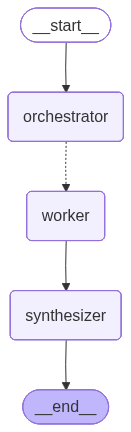

/Users/kimsiyeon/Desktop/gaida-2/04-langgraph/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sections(sections=[Sectio...대해 제언한다.')]), input_type=Sections])
  return self.__pydantic_serializer__.to_python(


In [ ]:
from langgraph.types import Send # 유동적으로 worker 노드를 실행
import operator

# Graph State
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add] # MessagesState 클래스 랑 거의 비슷함  -> State 덮어씌우는것이 아닌 계속 추가해주기 위함 (각 섹션 별 노드를 병렬로 돌릴때 뭐가 먼저 끝날지도 모르고 각 노드가 끝났다는 걸 알려면 계속 추가 해줘야함)
    final_report: str

# Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

# Nodes 
def orchestrator(state: State):
    # planner_llm의 structure output이 Sections 임
    report_sections = planner_llm.invoke(
        [
            SystemMessage(content='Generate a plan for report'),
            HumanMessage(content=f'Here is the report topic: {state['topic']}')
        ]
    )
    return {'sections': report_sections.sections}
    # Sections (sections= [Section(), Section(), ~])

def worker(state: WorkerState):
    section = llm.invoke(
        [
            SystemMessage(content='제공된 name과 description에 따라 보고서 섹션을 작성해라. 각 섹션 앞에는 서두를 넣지 말고, md 형식으로 작성.'),
            HumanMessage(content=f'섹션 name: {state['section'].name}\n 섹션 description: {state['section'].desciption}')
        ]
    )
    return {'completed_sections' : [section.content] }


def synthesizer(state: State):
    # 단순히 worker 들의 결과 합치기
    completed_sections = state['completed_sections']
    final_report ='\n\n ------------------- \n\n'.join(completed_sections)
    return {'final_report': final_report}

# Router
def assign_workers(state: State):
    plan = []
    for s in state['sections']:
        plan.append( Send('worker', {'section': s}) )# Send라는 객체를 plan 리스트에 append
    return plan

# Graph
workflow = StateGraph(State)

workflow.add_node(orchestrator)
workflow.add_node(worker)
workflow.add_node(synthesizer)

workflow.add_edge(START, 'orchestrator')
workflow.add_conditional_edges(
    'orchestrator',
    assign_workers,
    ['worker']
)

workflow.add_edge('worker', 'synthesizer')
workflow.add_edge('synthesizer', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({'topic': '치이카와 세계관에 대한 리포트 작성'})

In [ ]:
' --\n'.join(['a','b','c'])

'a -- \nb -- \nc'

In [18]:
from IPython.display import Markdown
Markdown(result['final_report'])

# 서론

본 리포트는 치이카와 세계관에 대해 깊이 있게 탐구하고 이해하기 위해 작성되었다. 치이카와는 독특하고 매력적인 캐릭터 및 스토리를 바탕으로 다양한 콘텐츠를 제공하며, 많은 이들의 관심과 사랑을 받고 있다. 이러한 세계관을 체계적으로 분석하고 소개하는 것은 팬들과 연구자들에게 유익한 정보를 제공할 뿐만 아니라, 더 나아가 치이카와의 문화적, 사회적 의미를 조명하는 데 중요한 역할을 한다. 따라서 본 보고서는 치이카와 세계관의 구성 요소와 특징을 종합적으로 고찰하여 그 가치를 재발견하고자 한다.

 ------------------- 

# 치이카와 세계관의 기본 개념

치이카와 세계관은 일본의 인기 일러스트와 캐릭터 시리즈를 중심으로 형성된 독특하고 사랑스러운 세계이다. 이 세계관은 귀여운 동물 형상의 작은 캐릭터들이 일상 속에서 겪는 다양한 에피소드와 감정을 담아내며 많은 사람들의 공감과 관심을 끌고 있다.

주요 캐릭터로는 치이카와(Chii-Kawa)를 비롯해, 하치와(Hachiwa), 우사기(Usagi) 등이 있으며 각기 개성 넘치는 특징과 매력을 지니고 있다. 이들은 작은 몸집에도 불구하고 각자의 개성과 상황에 맞는 다양한 감정을 표현하며, 이들의 이야기들은 독자들에게 따뜻한 위로와 웃음을 선사한다.

세계관의 설정은 현실과 판타지 요소가 적절히 섞여 있어, 귀엽고 단순한 외형과는 달리 깊이 있는 내용과 다양한 감정선을 표현할 수 있도록 구성되어 있다. 이러한 구성 덕분에 치이카와 시리즈는 단순한 캐릭터 굿즈를 넘어 하나의 문화 현상으로 자리매김했다.

 ------------------- 

# 치이카와 세계관의 역사와 배경

치이카와 세계관은 일본의 인기 캐릭터 시리즈인 '치이카와'를 중심으로 형성되었다. 치이카와 캐릭터는 귀엽고 작은 생명체들로 구성되어 있으며, 이들의 일상과 모험을 통해 따뜻한 감성과 유머를 전달하는 것이 특징이다.

세계관의 형성 배경은 주로 현대 사회에서 사람들이 느끼는 소소한 행복과 우정, 그리고 도전을 중심으로 한다. 처음에는 인터넷 만화를 통해 소규모로 시작되었으나, 빠른 속도로 팬층이 확장되면서 다양한 미디어와 상품으로 발전하였다.

치이카와 세계관은 작은 캐릭터들이 겪는 일상적인 이야기뿐만 아니라, 그들이 사는 세계의 자연과 사회적 관계에 대한 독특한 설정을 포함한다. 이를 통해 단순한 귀여움뿐 아니라 삶에 대한 긍정적인 메시지를 전달하며, 많은 사람들에게 공감을 얻고 있다.

이와 같은 발전 과정은 치이카와를 단순한 캐릭터 상품이 아닌, 하나의 문화 현상으로 자리매김하게 하였으며, 현재까지도 계속 진화하며 다양한 방식으로 이야기되고 있다.

 ------------------- 

# 치이카와 세계관의 주요 특징

## 스토리
치이카와 세계관은 소소하지만 따뜻한 일상을 중심으로 전개된다. 특별한 비극이나 대서사보다는 일상의 작은 순간들을 포착하여 감동과 공감을 이끌어낸다. 각 에피소드는 등장인물들이 겪는 작은 모험과 일상 속 도전, 우정과 성장의 이야기를 부드럽고 유머러스하게 담아내며 보는 이로 하여금 힐링과 위로를 경험하게 한다.

## 캐릭터 특성
치이카와의 캐릭터들은 귀여움과 개성 넘치는 디자인이 특징적이다. 각각의 캐릭터는 저마다 명확한 성격과 특성을 지니며, 친근감과 개성 있는 행동으로 독자들에게 깊은 인상을 남긴다. 작고 동글동글한 외형에 반해 다양한 감정 표현과 섬세한 심리 묘사가 어우러져 캐릭터들의 매력을 극대화한다. 치이카와를 비롯한 주인공들은 서로 다른 성격과 능력을 지니고 있어 이들이 주는 다채로운 상호작용이 이야기의 재미를 더한다.

## 세계관의 독특한 요소들
치이카와 세계관은 현실과 판타지가 절묘하게 조합된 독특한 무대를 바탕으로 한다. 캐릭터들이 생활하는 장소와 주변 환경은 작고 아담하면서도 따뜻한 분위기를 자아내며, 종종 비현실적인 요소들이 자연스럽게 녹아들어 신비롭고 매혹적인 느낌을 준다. 또한, 행동과 환경 묘사에서 느껴지는 세밀한 디테일은 이 세계가 단순한 만화 속 배경을 넘어 하나의 유기적인 생명체처럼 느껴지도록 한다. 이런 독특한 세계관은 치이카와 특유의 감성적이고 친근한 분위기를 유지하는 데 큰 역할을 한다.

 ------------------- 

# 치이카와 세계관의 사회적·문화적 영향

치이카와는 귀여운 캐릭터 디자인과 일상적인 이야기로 대중문화에 깊은 영향을 끼쳤다. 특히 SNS와 팬 커뮤니티를 중심으로 빠르게 확산되며, 팬덤 문화의 활성화에 큰 역할을 했다. 팬들은 치이카와 캐릭터들을 활용한 팬아트, 팬픽션, 상품 제작 등 다양한 2차 창작 활동을 활발히 전개하며, 이를 통해 치이카와 세계관이 더욱 확장되고 풍부해졌다.

사회적으로는 치이카와가 긍정적인 감성 자극과 스트레스 해소에 도움이 되는 콘텐츠로 인식되면서, 현대인의 정신 건강에 기여하는 요소로 주목받았다. 또한 캐릭터들이 보여주는 우정, 용기, 일상 속 소소한 행복 등의 주제는 다양한 연령층이 공감할 수 있는 메시지로 받아들여졌다. 이에 따라 치이카와는 대중문화뿐만 아니라 사회적 정서에도 긍정적인 영향을 준 사례로 평가받고 있다.

 ------------------- 

# 결론

본 리포트에서는 치이카와 세계관의 주요 특징과 그 독창성이 어떻게 대중의 관심을 이끌어내고 있는지를 분석하였다. 치이카와는 귀여운 캐릭터 디자인과 따뜻한 이야기 전개를 통해 폭넓은 연령층에게 사랑받고 있으며, 이는 캐릭터 산업 내에서 지속가능한 성공 요인으로 작용하고 있다. 또한, 치이카와 세계관은 소소한 일상 속에서 공감과 위로를 제공함으로써 현대 사회의 정서적 욕구를 충족시키고 있음을 알 수 있었다.

앞으로도 치이카와 세계관은 다양한 미디어와 상품으로 확장될 가능성이 크며, 꾸준한 콘텐츠 개발과 팬과의 소통을 통해 더욱 견고한 팬덤을 구축할 수 있을 것이다. 이를 위해서는 세계관의 일관성을 유지하면서도 새로운 이야기와 경험을 제공하는 것이 중요하다. 나아가, 글로벌 시장 진출을 고려한 번역과 문화적 맞춤화 전략도 치이카와의 미래 성장에 긍정적인 역할을 할 것이다.

따라서, 치이카와는 단순한 캐릭터를 넘어 문화적 현상으로 자리매김할 잠재력을 지니고 있으며, 그 가치를 극대화하기 위한 다각도의 노력이 지속되어야 할 것이다.

In [ ]:
# worker node 함수 내부에 langchain agent tool
# langchain agent 에게 websearch tool 배치 (Tavily Websearch)

import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
from tavily import TavilyClient

load_dotenv()

TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


@tool
def tavily_websearch_tool(  
    query: str,
    topic: Literal['general', 'news', 'finance'] = 'general',
    max_results: int = 5,  # = 뒤에는 기본값
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

class SectionContent(BaseModel):
    content: str = Field(..., description='작성된 보고서 섹션 내용 (md 형식)')


AGENT_SYSTEM_PROMPT = f""" 
                        제공된 name과 description에 따라 보고서 섹션을 작성해라. 
                        각 섹션 앞에는 서두를 넣지 말고, md 형식으로 작성.
                        LLM관련 내용이면 tavily_websearch_tool을 사용해 최신 정보를 검색해라.
                      """

agent = create_agent(
    model = llm,
    tools = [tavily_websearch_tool],
    system_prompt= AGENT_SYSTEM_PROMPT,
    response_format= SectionContent
)


# worker 노드 

def worker(state: WorkerState):
    result = agent.invoke(
        {
            'messages': [
                {
                'role': 'user',
                'content': f"섹션 name: {state['section'].name}\n섹션 description: {state['section'].desciption}"
                }
            ]
        }
    )


   

    return {'completed_sections' : [result['structured_response'].content] }

'''
{
'messages':  [ HumanMessage() , AIMessage()],
‘structured_response’ : SectionContent(content=  ) 

}
'''

"\n{\n'messages':  [ HumanMessage() , AIMessage()],\n‘structured_response’ : SectionContent(content=  ) \n\n}\n"

In [35]:

import pprint

result = agent.invoke({ 'messages': [
                { 'role': 'user',
                 'content': '섹션 name: 소개 섹션 , description: LLM(대형 언어 모델) 스케일링 법칙의 기본 개념과 중요성을 설명한다. 이러한 법칙이 인공지능 연구와 응용에 미치는 영향에 대해 간략히 소개한다.'}

            ]
        }
    )

pprint.pprint(result)
   

{'messages': [HumanMessage(content='섹션 name: 소개 섹션 , description: LLM(대형 언어 모델) 스케일링 법칙의 기본 개념과 중요성을 설명한다. 이러한 법칙이 인공지능 연구와 응용에 미치는 영향에 대해 간략히 소개한다.', additional_kwargs={}, response_metadata={}, id='373b4863-a925-4c5f-9951-3572684f2d8b'),
              AIMessage(content='', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 282, 'total_tokens': 322, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_e6090e88f9', 'id': 'chatcmpl-DITuMXlgsgk0XeUTUDusMni8RKVZL', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce0c0-91f4-7830-9c2f-79422be24ace-0', tool_calls=[{'name': 'tavily_websearch_tool', 'args': {'query': 'LLM scaling 

In [ ]:
{'messages': [HumanMessage(content='섹션 name: 소개 섹션 description: LLM(대형 언어 모델) 스케일링 법칙의 기본 개념과 중요성을 설명한다. 이러한 법칙이 인공지능 연구와 응용에 미치는 영향에 대해 간략히 소개한다.', additional_kwargs={}, response_metadata={}, id='08afd15d-6954-4bd7-b3c5-878786242384'),
              AIMessage(content='{"content":"# 소개 섹션\\n\\n대형 언어 모델(LLM, Large Language Models)의 스케일링 법칙은 모델 크기, 학습 데이터 양, 계산 자원과 같은 요소들이 모델 성능에 미치는 영향을 수학적으로 또는 경험적으로 규명한 개념이다. 이 법칙에 따르면, 모델의 크기와 학습 데이터가 증가할수록 언어 모델의 성능이 예측 가능하고 일관되게 향상된다는 특징이 있다.\\n\\n스케일링 법칙의 중요성은 AI 연구와 실용적 애플리케이션 개발에서 매우 크다. 이를 통해 연구자와 개발자는 자원 투자 대비 최적의 성능 향상 방안을 계획할 수 있으며, 실제로 대규모 언어 모델이 놀라운 성능을 발휘하는 배경을 이해할 수 있다. 또한, 스케일링 법칙은 모델 설계, 학습 전략, 하드웨어 요구사항 등을 체계적으로 분석하는 데 토대를 제공하여 인공지능 기술 발전에 핵심적인 역할을 수행한다.\\n\\n결과적으로, LLM 스케일링 법칙은 인공지능 분야에서 대형 모델의 효과적인 개발과 응용을 가능하게 하며, 보다 정교하고 강력한 자연어 처리 시스템 구축에 기여한다."}', additional_kwargs={'parsed': None, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 294, 'prompt_tokens': 263, 'total_tokens': 557, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_fa4407aec8', 'id': 'chatcmpl-DITmoF2gD184RnN8BZCv1WpHvVqAs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ce0b9-6cb1-7090-a3fa-cb0e8474b7a0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 263, 'output_tokens': 294, 'total_tokens': 557, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})],
 'structured_response': SectionContent(content='# 소개 섹션\n\n대형 언어 모델(LLM, Large Language Models)의 스케일링 법칙은 모델 크기, 학습 데이터 양, 계산 자원과 같은 요소들이 모델 성능에 미치는 영향을 수학적으로 또는 경험적으로 규명한 개념이다. 이 법칙에 따르면, 모델의 크기와 학습 데이터가 증가할수록 언어 모델의 성능이 예측 가능하고 일관되게 향상된다는 특징이 있다.\n\n스케일링 법칙의 중요성은 AI 연구와 실용적 애플리케이션 개발에서 매우 크다. 이를 통해 연구자와 개발자는 자원 투자 대비 최적의 성능 향상 방안을 계획할 수 있으며, 실제로 대규모 언어 모델이 놀라운 성능을 발휘하는 배경을 이해할 수 있다. 또한, 스케일링 법칙은 모델 설계, 학습 전략, 하드웨어 요구사항 등을 체계적으로 분석하는 데 토대를 제공하여 인공지능 기술 발전에 핵심적인 역할을 수행한다.\n\n결과적으로, LLM 스케일링 법칙은 인공지능 분야에서 대형 모델의 효과적인 개발과 응용을 가능하게 하며, 보다 정교하고 강력한 자연어 처리 시스템 구축에 기여한다.')}

In [40]:
# Graph
workflow = StateGraph(State)

workflow.add_node(orchestrator)
workflow.add_node(worker)
workflow.add_node(synthesizer)

workflow.add_edge(START, 'orchestrator')
workflow.add_conditional_edges(
    'orchestrator',
    assign_workers,
    ['worker']
)

workflow.add_edge('worker', 'synthesizer')
workflow.add_edge('synthesizer', END)

graph = workflow.compile()

# display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({'topic': 'LLM에 대한 리포트 작성'})


/Users/kimsiyeon/Desktop/gaida-2/04-langgraph/.venv/lib/python3.13/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sections(sections=[Sectio...를 마무리한다.')]), input_type=Sections])
  return self.__pydantic_serializer__.to_python(


In [41]:
from IPython.display import Markdown
Markdown(result['final_report'])

# 서론

최근 자연어 처리 분야에서 큰 주목을 받고 있는 LLM(Large Language Model)은 방대한 양의 텍스트 데이터를 학습하여 인간과 유사한 수준의 언어 이해 및 생성 능력을 갖춘 인공지능 모델을 의미한다. 이러한 LLM은 문서 작성, 번역, 요약, 질의응답 등 다양한 언어 기반 작업에서 뛰어난 성능을 보여주며, 인공지능 기술 발전의 핵심 동력으로 자리 잡고 있다.

LLM의 중요성은 데이터 중심의 디지털 사회에서 더욱 부각되고 있다. 정보의 폭증과 복잡성 증가에 대응해 효율적이고 정확한 언어처리 능력은 기업과 연구기관뿐만 아니라 일상생활에서도 필수적인 요소가 되었다. 이에 따라 LLM은 자동화, 생산성 향상, 혁신적인 서비스 개발 등 다양한 분야에서 혁신의 핵심 도구로 활용되고 있다.

 ------------------- 

# LLM의 역사와 발전

대규모 언어 모델(LLM, Large Language Models)은 자연어 처리를 혁신적으로 변화시킨 인공지능 모델로, 매우 방대한 텍스트 데이터를 기반으로 학습하여 사람과 유사한 언어 생성 능력을 갖추고 있다. LLM의 역사는 초기 인공지능 연구부터 시작되어 현대에 이르기까지 꾸준한 발전을 거쳐왔다.

## 초기 인공지능과 신경망의 탄생

1958년, 프랭크 로젠블랫은 헤브 알고리즘과 기계 학습의 선구적인 연구를 통합하여 최초의 인공 신경망인 퍼셉트론(Mark 1 Perceptron)을 개발했다. 그러나 그 이후 신경망 연구는 한동안 침체를 겪었고, AI와 기계 학습 분야가 분리되는 양상을 보였다.

## 딥러닝과 대규모 학습의 부흥

2010년대 이후 심층 신경망과 딥러닝 기술의 발전으로 대규모 언어 모델이 본격적으로 연구되기 시작했다. 인공지능 연구자들은 방대한 텍스트 데이터와 계산 자원을 활용해 사전 학습(pre-training)된 모델을 개발하기 시작했으며, 이 과정에서 자연어 이해와 생성 능력이 비약적으로 향상되었다.

## 주요 연구 성과 및 모델

- **GPT 시리즈 (OpenAI, 2018~현재)** : GPT-1부터 GPT-4에 이르기까지 사람과 유사한 텍스트 생성 능력을 발전시켜 왔다. 특히 GPT-3와 GPT-4는 수십억 개의 매개변수와 대용량 데이터셋으로 학습하여 다양한 언어 작업에서 뛰어난 성능을 보였다.

- **T5, XLNet, BERT 등** : 다양한 아키텍처로 자연어 처리 능력을 높이며, 사전 학습과 미세 조정을 통한 효과적인 전이학습을 가능하게 했다.

- **LLaMA (Meta), 오픈 소스 모델들** : LLaMA 등은 오픈 소스로 공개되어 연구자와 개발자들이 LLM을 더욱 쉽게 이해하고 활용할 수 있는 기반을 마련했다.

## 발전의 의미와 활용

LLM은 단순한 규칙 기반 언어 처리 시스템에서 시작하여, 지금은 인간과 비슷한 수준의 텍스트 생성, 이해, 심지어 코드 작성까지 가능한 AI 도구로 성장했다. 이들은 교육, 의료, 소프트웨어 개발, 고객 지원 등 다양한 분야에서 혁신적인 역할을 수행하고 있다.

## 결론

LLM의 역사는 인공지능과 자연어 처리 기술의 진화와 함께하며, 끊임없는 연구와 기술 발전으로 오늘날의 강력한 인공지능 도구가 탄생했다. 앞으로도 더 큰 규모와 더 정교한 모델이 등장할 것으로 전망된다.

 ------------------- 

대규모 언어 모델(LLM)은 방대한 양의 텍스트 데이터를 기반으로 작동하는 기계 학습 모델로, 주로 인공 신경망 중에서도 트랜스포머(Transformer) 구조를 활용한다. LLM의 핵심 원리는 텍스트를 작은 단위인 토큰(token)으로 분할하는 토큰화(tokenization) 과정을 거친 후, 각 토큰의 연속성에 따른 패턴을 학습하여 다음에 올 토큰을 예측하는 방식이다.

주요 알고리즘으로는 트랜스포머 기반의 자기 주의 메커니즘(self-attention)이 사용되며, 이는 문맥 내 단어 간의 관계를 효율적으로 파악하여 자연스러운 문장 생성과 높은 언어 이해 능력을 가능하게 한다. 모델 학습은 수십억 개 이상의 파라미터(parameter)를 가진 신경망을 이용해 대량의 텍스트 데이터를 사전 학습(pre-training)하며, 이후 특정 작업에 맞는 미세 조정(fine-tuning) 단계를 거친다.

LLM은 연산 과정에서 병렬 처리가 용이하여 GPU 등의 고성능 하드웨어를 활용해 학습하며, 학습된 모델은 입력된 텍스트에 대해 확률적으로 가장 적합한 출력을 생성한다. 이러한 구조와 알고리즘을 통해 LLM은 번역, 요약, 질문 답변, 창작 등 다양한 자연어처리(NLP) 작업에 뛰어난 성능을 발휘한다.

 ------------------- 

# LLM의 응용 분야

대규모 언어 모델(LLM)은 자연어 처리(NLP)의 혁신을 이끌며 다양한 분야에서 놀라운 성과를 보여주고 있다. 이 모델들은 복잡한 언어 처리 작업을 효과적으로 수행하며, 주요 응용 분야는 다음과 같다.

## 1. 자연어 생성 (Text Generation)
LLM은 인간과 유사한 자연스러운 언어 생성 능력을 갖추고 있어, 블로그 글, 기사, 스크립트, 요약, 소셜 미디어 게시물 등을 생성하는 데 활용된다. 입력된 텍스트를 자연스럽게 이어가거나 새로운 콘텐츠를 생성할 수 있다.

## 2. 질의응답 시스템 (Question Answering)
사용자가 제시하는 질문에 대해 대규모 텍스트 자료에서 가장 적합한 답변을 찾아 제공한다. 이는 고객지원, 정보검색, 교육 등 다양한 서비스에 적용된다.

## 3. 기계번역 및 요약 (Translation and Summarization)
LLM은 문맥을 폭넓게 이해하는 능력을 바탕으로 고품질 번역을 수행하며, 길고 복잡한 문서를 요약해 핵심 정보를 효과적으로 전달한다. 특히 기계번역 분야에서는 전통적인 NMT(Neural Machine Translation)를 보완하거나 발전시키는 역할을 한다.

## 4. 코드 생성 (Code Generation)
프로그래밍 주석이나 명령어를 입력받아 자동으로 코드를 생성하는 데에도 사용된다. 이는 소프트웨어 개발 생산성 향상에 기여하며, 예를 들면 GitHub Copilot 등이 있다.

## 5. 감성 분석 및 데이터 분류 (Sentiment Analysis and Text Classification)
소비자 리뷰, 소셜 미디어 게시물, 이메일 등 다양한 텍스트 데이터를 분석해 긍정적, 부정적, 중립적 감정을 자동 분류하며, 마케팅 및 고객 서비스 분야에서 활용되고 있다.

## 6. 전문 분야별 활용
- 법률: 방대한 법률 문서 검색, 증거 자료 추출 및 작성 지원
- 금융: 사기 탐지, 리스크 분석 강화
- 의료과학: 진단 보조, 의학 문헌 분석 및 신약 개발
- 소재과학: 연구 논문 데이터 추출 및 신소재 개발 가속화

## 결론
LLM은 텍스트 생성부터 전문 분야 지식 추출, 자동화된 의사결정 지원까지 다양한 영역에서 활용되며, 인공지능의 산업 적용을 가속화하고 있다. 향후 기술 발전과 함께 더욱 효율적이고 정밀한 응용들이 기대된다.

 ------------------- 

## LLM의 장점
- 방대한 데이터 학습: 인간의 언어를 이해하고 자연스럽게 답변을 생성할 수 있어 다양한 분야에서 활용 가능하다.
- 고도의 언어 이해력: 문서 요약, 번역, 고객 문의 자동 응답 등 복잡한 언어 작업을 수행할 수 있다.
- 작업 자동화: 예를 들어, 단순한 글쓰기 도우미를 넘어 LLM Agent는 고객 불만에 맞춤형 이메일 작성 등 일을 대신 처리하는 비서 역할까지 수행할 수 있다.

## LLM의 단점 및 현재 한계점
- 최신 정보 반영 어려움: 모델이 학습한 데이터가 최신이 아니면 시의적절한 답변 제공이 어렵다.
- 편향성과 차별 가능성: 균형 잡히지 않은 데이터로 인해 편향된 답변이나 차별적 표현을 할 수 있다.
- 높은 비용과 자원 요구: 수십억 개의 매개변수를 가진 대규모 모델은 운영과 유지에 많은 비용과 컴퓨팅 자원이 필요하다.
- 정확성 문제: 일부 문답에서 부정확하거나 어색한 답변을 생성할 수 있어 신뢰성 문제를 갖는다.
- 기술적 복잡성: 모델의 구조가 복잡해 문제 해결이나 오류 수정이 어렵다.
- 보안 및 개인정보 문제: 민감한 정보 취급 시 보안 위협이 존재할 수 있다.

LLM은 AI 기술 발전의 중요한 전환점이지만, 위와 같은 한계점들이 존재하여 모든 문제에 대한 완전한 해결책이라기보다는 보완과 발전이 필요한 단계임을 알 수 있다.

 ------------------- 

## 미래 전망 및 결론

대규모 언어 모델(LLM)의 미래는 기술적 진화와 사회적 영향 측면에서 매우 밝고 다각적입니다. 앞으로 LLM은 데이터 규모의 확대와 언어 다양성 향상, 일반화 능력의 진보를 통해 더욱 정교하고 폭넓은 활용이 가능해질 것입니다. 2025년을 전후로 LLM은 효율성, 정확성, 윤리성 면에서도 큰 발전을 이루며, 다양한 산업 분야에서 핵심 역할을 수행할 전망입니다.

특히 LLM은 자동화와 업무 생산성 향상을 촉진하고, 맞춤형 AI 지원을 통해 복잡한 현실 문제 해결에도 기여할 것으로 기대됩니다. 이를 통해 의료, 금융, 제조업 등 여러 분야에서 혁신이 가속화되고 새로운 비즈니스 모델이 등장할 것입니다. 또한 LLM을 기반으로 한 기술들은 더 안전하고 포괄적인 사용자 경험을 제공하며, 기술 접근성을 높여 산업 전반의 디지털 전환을 견인할 것입니다.

그러나 이러한 기술적 진보와 함께 윤리적 고려, 개인정보 보호, 그리고 지속 가능성 문제 역시 중요한 과제로 남아 있습니다. AI의 책임성 확보 및 편향성 제거 등 신중한 관리와 정책 마련이 필수적이며, 사회 전반에 걸친 다각도의 논의와 협력이 요구됩니다.

결론적으로, LLM 기술은 미래 사회와 산업을 재편할 강력한 도구로 자리매김할 것이며, 이를 통해 인간의 삶과 일하는 방식을 근본적으로 향상시킬 잠재력을 지니고 있습니다. 본 보고서가 보여준 LLM의 현황과 전망을 바탕으로, 지속적인 연구 개발과 윤리적 책임의 균형을 이루는 노력이 필요하다고 하겠습니다.

# Evalutor - optimizer (평가 - 최적화)
- 답변 생성용 LLM과 답변 평가용 LLM
- 만족스러운 평가가 될때까지 응답 재생성
- "성공" 기준이 매우 명확할 때 사용.

In [ ]:
class State(TypedDict):
    joke: str
    topic: str
    feed_back: str
    funny_or_not : str

# 평가 담당 llm이 사용할 structured output schema
class Feedback(BaseModel):
    grade: Literal['funny', 'not funny'] = Field(..., description='농담이 재밌는지 아닌지 판단')
    feed_back: str = Field(description='농담이 재미 없다면, 발전시킬 수 있도록 피드백 제공')

evaluator_llm = llm.with_structured_output(Feedback)

